# **Reflective Portfolio Week 3**

## **Case Study 1: Evaluating Data Collection Pipelines for Melbourne Businesses on a Large-Scale**
---

### **Context**
Keystone requires a high-integrity database of Melbourne businesses to identify community and employment opportunities for Keystone participants. A core operational constraint is that the dataset should preferably incorporate accessibility metadata (e.g., wheelchair access, accessible facilities) alongside standard business attributes (phone, website, suburb). The goal during this research phase is to establish a scalable, cost-effective data collection pipeline and any related documentation before commencing the process.
###**Investigation**
OpenStreetMap and Yellow Pages were evaluated as zero-cost options, however both platforms had significant gaps in data. They frequently omitted core contact details like phone numbers and websites. Crucially, neither platform captures any accessibility features data which Keystone would prefer.

Using Google Maps API provided high data accuracy and even some accessibility features for each business. The main drawbacks of this method are the costs and practicality. The API enforces a strict cap of 60 results per search query. Scaling this to retrieve hundreds and thousands of results across Melbourne would result in many duplicates which are both time and cost-inefficient.

### **Solution**
The optimal extraction path identified is Apify’s official Google Maps Scraper. Unlike the standard API, Apify enables large-scale, automated extraction in a single run, retrieving complete contact records and accessibility tags without duplicating entries. Although Apify operates on a paid model, the elimination of duplicate processing and manual cleanup yields the highest operational efficiency and lowest total cost.

| Feature / Criteria | OpenStreetMap / Yellow Pages | Google Maps API | Apify Google Maps Scraper |
| :--- | :--- | :--- | :--- |
| **Accessibility Data** | None | Included | Included |
|**Contact Information** | Unreliable | Reliable | Reliable|
| **Query Limits** | None | 60 results per search | Large-scale single run |
| **Duplicate Risk** | Low | High | Low  |
| **Cost Efficiency** | Free | High | Medium |

## **Case Study 2: Optimisation Strategies for High-Volume Analytics Dashboard**
---

### **Context**
As project planning transitions toward dashboard development, early expectations are that client-side rendering latency represents a primary technical risk. Historical implementation demonstrates that loading large datasets directly into a browser-based dashboard causes severe lag during user filtering operations. To prevent performance bottlenecks, optimisation strategies must be defined prior to code development.
###**Investigation**
Pre-processed Boolean arrays normalise strings into boolean arrays at startup to eliminate repeating expensive string conversions during runtime.

Applying function caching to expensive operations prevents redundant re-computations when inputs remain unchanged.

Server-side pagination and sorting moves execution from the client browser to the backend server ensure that only active display slices are transferred over the network. This means when we make our dashboard, only the results on the first page are calculated rather than the whole dataset which could boost operations by a lot.


### **Solution**
The optimisation phase of the project is after developement of the base database and dashboard, which won't happen for a few weeks. Based on our evaluation, server-side pagination and sorting would serve as the primary optimisation made to our dashboard. This is because by offloading execution to the server and transmitting page-sized payloads, we address the root cause of client-side latency. We will also consider adding the other smaller optimisations like caching, pre-processed boolean arrays and other methods.

This approach guarantees that both backend dataset query processing and frontend client rendering remain lightweight, responsive, and fully scalable as Keystone’s business database grows.

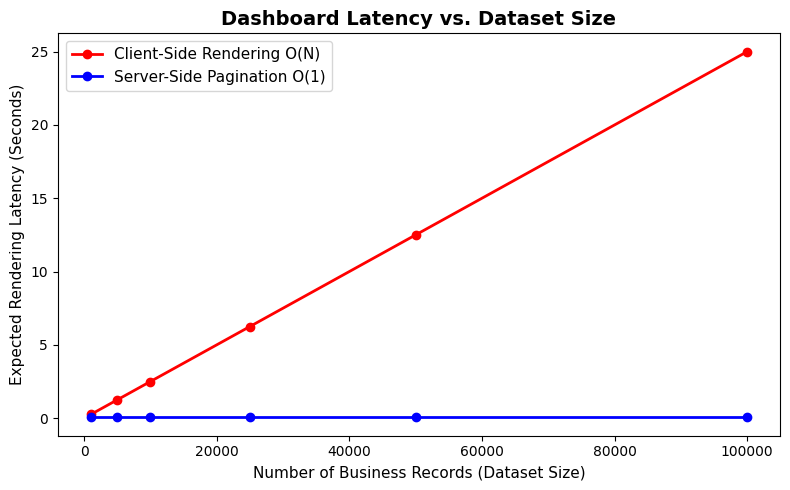

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dataset_sizes = np.array([1000, 5000, 10000, 25000, 50000, 100000]) #Example dataset sizes

client_side_latency = dataset_sizes * 0.00025 #O(N) Linear growth as if dataset has N entries, all N records must be serialized.

server_side_latency = np.full_like(dataset_sizes, 0.05, dtype=float) #O(1) as regardless of dataset size, server slices the result and transfers only K (constant) amount of rows over the network.

plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, client_side_latency, marker='o', color='red', linewidth=2, label='Client-Side Rendering O(N)')
plt.plot(dataset_sizes, server_side_latency, marker='o', color='blue', linewidth=2, label='Server-Side Pagination O(1)')

plt.title('Dashboard Latency vs. Dataset Size', fontsize=14, fontweight='bold')
plt.xlabel('Number of Business Records (Dataset Size)', fontsize=11)
plt.ylabel('Expected Rendering Latency (Seconds)', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()